# Multi-Element SBP-DG Advection: h-Refinement Convergence

This notebook implements a multi-element SBP-DG solver for linear advection with:

1. Diagonal inverse mass matrix $W^{-1} = 1/w_i$ (no dense projected inverse mass)
2. Flux differencing volume term $2(D \circ F_S)\mathbf{1}$ in OOM-safe form
3. Entropy-stable SAT surface coupling

Blueprint reference: Chen and Shu (2020), entropy-stable SBP-DG framework.

In [39]:
import sys

from pathlib import Path



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from IPython.display import display



notebook_dir = Path.cwd()

project_root = notebook_dir.parent.parent

if str(project_root) not in sys.path:

    sys.path.insert(0, str(project_root))



from src.bases.simplex_2d import generate_subdivided_triangle

from src.bases.vandermonde import grad_vandermonde_2d_dubiner, vandermonde_2d_dubiner

from src.core.connectivity import build_connectivity

from src.core.generators import get_reference_data

from src.geometry.metrics import compute_geometric_factors

from src.reconstruction import build_differentiation_matrices

from src.reconstruction.boundary import build_fmask_table1



k = 3

N = k + 1

velocity = np.array([1.0, 0.0])



ref_data = get_reference_data('table1', k)

xi_ref = ref_data['xi']

eta_ref = ref_data['eta']

weights_2d = ref_data['weights']

weights_1d = ref_data['weights_1d']

Np = len(xi_ref)

nfp = len(weights_1d)



print(f'Polynomial degree k={k}, Np={Np}, nfp={nfp}')


Polynomial degree k=3, Np=18, nfp=4


In [40]:
def exact_solution_multi(X: np.ndarray, _Y: np.ndarray, t: float) -> np.ndarray:

    """Return exact solution q(x,y,t)=sin(x-t) on all nodal points."""

    _ = _Y

    return np.sin(X - t)





def build_face_mask() -> np.ndarray:

    """Build reference face-node table in HW face order: [bottom, hypotenuse, left]."""

    bary_coords = np.column_stack([

        (eta_ref + 1.0) / 2.0,

        (-xi_ref - eta_ref) / 2.0,

        (xi_ref + 1.0) / 2.0,

    ])

    fmask_raw = build_fmask_table1(bary_coords)

    # build_fmask_table1 returns [L3=0, L1=0, L2=0]; remap to HW [s=-1, r+s=0, r=-1]

    return fmask_raw[:, [1, 2, 0]]





def generate_and_build_mesh(n_div: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int]:

    """Generate triangulation and element connectivity for a subdivided triangle mesh."""

    nodes, triangles = generate_subdivided_triangle(n_div)

    EToV = np.asarray(triangles, dtype=int)

    EToE, EToF = build_connectivity(EToV)

    K = EToV.shape[0]

    return np.asarray(nodes, dtype=float), EToV, EToE, EToF, K





def build_global_index_maps(

    EToE: np.ndarray,

    EToF: np.ndarray,

    fmask: np.ndarray,

    K: int,

    Np_local: int,

) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    """Build vmapM/vmapP with reversed neighbor ordering and boundary mask."""

    nfp_local = fmask.shape[0]

    vmapM = np.zeros((3 * nfp_local, K), dtype=int)

    vmapP = np.zeros((3 * nfp_local, K), dtype=int)

    mapB = np.zeros((3 * nfp_local, K), dtype=bool)



    for k_elem in range(K):

        for face in range(3):

            local_nodes = fmask[:, face]

            interior = k_elem * Np_local + local_nodes

            vmapM[face * nfp_local:(face + 1) * nfp_local, k_elem] = interior



            nbr_elem = EToE[k_elem, face]

            nbr_face = EToF[k_elem, face]



            if nbr_elem == k_elem:

                vmapP[face * nfp_local:(face + 1) * nfp_local, k_elem] = interior

                mapB[face * nfp_local:(face + 1) * nfp_local, k_elem] = True

            else:

                nbr_nodes = fmask[:, nbr_face]

                exterior = nbr_elem * Np_local + nbr_nodes

                vmapP[face * nfp_local:(face + 1) * nfp_local, k_elem] = exterior[::-1]



    return vmapM, vmapP, mapB





def map_to_physical(nodes: np.ndarray, EToV: np.ndarray, K: int) -> tuple[np.ndarray, np.ndarray]:

    """Map reference nodes to all physical elements in vectorized column layout (Np,K)."""

    X = np.zeros((Np, K))

    Y = np.zeros((Np, K))



    for k_elem in range(K):

        v1, v2, v3 = nodes[EToV[k_elem]]

        X[:, k_elem] = -0.5 * (xi_ref + eta_ref) * v1[0] + 0.5 * (xi_ref + 1.0) * v2[0] + 0.5 * (eta_ref + 1.0) * v3[0]

        Y[:, k_elem] = -0.5 * (xi_ref + eta_ref) * v1[1] + 0.5 * (xi_ref + 1.0) * v2[1] + 0.5 * (eta_ref + 1.0) * v3[1]



    return X, Y





def compute_metrics_vectorized(nodes: np.ndarray, EToV: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

    """Compute element-wise geometric factors and characteristic size h_min."""

    K = EToV.shape[0]

    J = np.zeros(K)

    rx = np.zeros(K)

    ry = np.zeros(K)

    sx = np.zeros(K)

    sy = np.zeros(K)

    h_min = np.zeros(K)



    for k_elem in range(K):

        v1, v2, v3 = nodes[EToV[k_elem]]

        metrics = compute_geometric_factors(v1, v2, v3)

        J[k_elem] = metrics['J']

        rx[k_elem] = metrics['rx']

        ry[k_elem] = metrics['ry']

        sx[k_elem] = metrics['sx']

        sy[k_elem] = metrics['sy']



        edge_lengths = np.array([

            np.linalg.norm(v2 - v1),

            np.linalg.norm(v3 - v2),

            np.linalg.norm(v1 - v3),

        ])

        h_min[k_elem] = np.min(edge_lengths)



    return J, rx, ry, sx, sy, h_min





def build_face_geometry(nodes: np.ndarray, EToV: np.ndarray, fmask: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    """Compute physical outward normals and face Jacobians for all elements."""

    K = EToV.shape[0]

    nfp_local = fmask.shape[0]

    nx = np.zeros((3 * nfp_local, K))

    ny = np.zeros((3 * nfp_local, K))

    J_face = np.zeros((3 * nfp_local, K))



    for k_elem in range(K):

        v1, v2, v3 = nodes[EToV[k_elem]]

        edges = [v2 - v1, v3 - v2, v1 - v3]



        for face, edge in enumerate(edges):

            length = np.linalg.norm(edge)

            normal = np.array([edge[1], -edge[0]]) / length

            sl = slice(face * nfp_local, (face + 1) * nfp_local)

            nx[sl, k_elem] = normal[0]

            ny[sl, k_elem] = normal[1]

            J_face[sl, k_elem] = 0.5 * length



    return nx, ny, J_face


In [41]:
def build_extraction_matrix(fmask: np.ndarray, Np_local: int) -> np.ndarray:

    """Build boolean extraction matrix E mapping volume nodes to face nodes."""

    nfp_local = fmask.shape[0]

    E = np.zeros((3 * nfp_local, Np_local))

    for face in range(3):

        E[face * nfp_local:(face + 1) * nfp_local, fmask[:, face]] = np.eye(nfp_local)

    return E





fmask = build_face_mask()

E = build_extraction_matrix(fmask, Np)

W_inv = 1.0 / weights_2d



V_nodal = vandermonde_2d_dubiner(xi_ref, eta_ref, k)

Vr, Vs = grad_vandermonde_2d_dubiner(xi_ref, eta_ref, k)

D_r_seed, D_s_seed = build_differentiation_matrices(V_nodal, Vr, Vs, w=weights_2d)



const_r_defect = float(np.max(np.abs(D_r_seed @ np.ones(Np))))

const_s_defect = float(np.max(np.abs(D_s_seed @ np.ones(Np))))



print('Pre-flight consistency check')

print(f'  ||D_r_seed * 1||_inf = {const_r_defect:.3e}')

print(f'  ||D_s_seed * 1||_inf = {const_s_defect:.3e}')

print('  Using seed differentiation matrices directly for SBP-DG evolution')


Pre-flight consistency check
  ||D_r_seed * 1||_inf = 8.327e-16
  ||D_s_seed * 1||_inf = 8.882e-16
  Using seed differentiation matrices directly for SBP-DG evolution


In [42]:
A_RK = np.array([

    0.0,

    -567301805773.0 / 1357537059087.0,

    -2404267990393.0 / 2016746695238.0,

    -3550918686646.0 / 2091501179385.0,

    -1275806237668.0 / 842570457699.0,

])

B_RK = np.array([

    1432997174477.0 / 9575080441755.0,

    5161836677717.0 / 13612068292357.0,

    1720146321549.0 / 2090206949498.0,

    3134564353537.0 / 4481467310338.0,

    2277821191437.0 / 14882151754819.0,

])

C_RK = np.array([0.0, 0.1496590219993, 0.3704009573644, 0.6222557631345, 0.9582818314695])





def flux_differencing_linear(D: np.ndarray, q: np.ndarray, adv_coeff: np.ndarray) -> np.ndarray:

    """Compute 2*(D ∘ F_S)*1 for linear two-point flux without forming Np×Np×K tensor."""

    row_sum = np.sum(D, axis=1, keepdims=True)

    return adv_coeff[np.newaxis, :] * ((D @ q) + row_sum * q)





def entropy_stable_flux(qM: np.ndarray, qP: np.ndarray, v_n: np.ndarray) -> np.ndarray:

    """Entropy-stable flux for linear advection: central flux plus Lax-Friedrichs dissipation."""

    return 0.5 * v_n * (qM + qP) - 0.5 * np.abs(v_n) * (qP - qM)





def compute_rhs_sbp_dg(

    Q: np.ndarray,

    X: np.ndarray,

    Y: np.ndarray,

    t: float,

    D_r: np.ndarray,

    D_s: np.ndarray,

    E: np.ndarray,

    W_inv_diag: np.ndarray,

    J: np.ndarray,

    rx: np.ndarray,

    ry: np.ndarray,

    sx: np.ndarray,

    sy: np.ndarray,

    vmapM: np.ndarray,

    vmapP: np.ndarray,

    mapB: np.ndarray,

    nx: np.ndarray,

    ny: np.ndarray,

    J_face: np.ndarray,

    weights_1d_local: np.ndarray,

) -> np.ndarray:

    """Compute semi-discrete SBP-DG RHS with flux differencing volume and SAT surface terms."""

    q = Q[0]



    a_x, a_y = velocity

    coeff_r = a_x * rx + a_y * ry

    coeff_s = a_x * sx + a_y * sy

    volume_term = -(

        flux_differencing_linear(D_r, q, coeff_r)

        + flux_differencing_linear(D_s, q, coeff_s)

    )



    q_flat = q.flatten(order='F')

    qM = q_flat[vmapM]

    qP = q_flat[vmapP].copy()



    X_face = X.flatten(order='F')[vmapM]

    Y_face = Y.flatten(order='F')[vmapM]

    q_bc = exact_solution_multi(X_face, Y_face, t)

    qP[mapB] = q_bc[mapB]



    v_n = velocity[0] * nx + velocity[1] * ny

    f_nk = v_n * qM

    f_hat = entropy_stable_flux(qM, qP, v_n)

    delta_flux = f_hat - f_nk



    face_w = np.tile(weights_1d_local, 3)

    scaled_delta = delta_flux * face_w[:, np.newaxis] * J_face

    surface_integral = E.T @ scaled_delta

    sat_term = (W_inv_diag[:, np.newaxis] / J[np.newaxis, :]) * surface_integral



    rhs_q = volume_term - sat_term

    return rhs_q[np.newaxis, :, :]





def solve_advection_sbp_dg(

    n_div: int,

    t_final: float,

    CFL: float,

    D_r: np.ndarray,

    D_s: np.ndarray,

    E: np.ndarray,

    W_inv_diag: np.ndarray,

) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:

    """Solve linear advection on a subdivided mesh and return final numerical/exact states."""

    nodes, EToV, EToE, EToF, K = generate_and_build_mesh(n_div)



    X, Y = map_to_physical(nodes, EToV, K)

    J, rx, ry, sx, sy, h_min = compute_metrics_vectorized(nodes, EToV)

    vmapM, vmapP, mapB = build_global_index_maps(EToE, EToF, fmask, K, Np)

    nx, ny, J_face = build_face_geometry(nodes, EToV, fmask)



    Q = exact_solution_multi(X, Y, 0.0)[np.newaxis, :, :]

    residual = np.zeros_like(Q)



    V_max = float(np.linalg.norm(velocity))

    dt_global = CFL * np.min(h_min) / (V_max * (N ** 2))



    t = 0.0

    while t < t_final - 1e-14:

        dt = min(dt_global, t_final - t)

        residual.fill(0.0)



        for stage in range(5):

            t_stage = t + C_RK[stage] * dt

            rhs = compute_rhs_sbp_dg(

                Q=Q,

                X=X,

                Y=Y,

                t=t_stage,

                D_r=D_r,

                D_s=D_s,

                E=E,

                W_inv_diag=W_inv_diag,

                J=J,

                rx=rx,

                ry=ry,

                sx=sx,

                sy=sy,

                vmapM=vmapM,

                vmapP=vmapP,

                mapB=mapB,

                nx=nx,

                ny=ny,

                J_face=J_face,

                weights_1d_local=weights_1d,

            )

            residual = A_RK[stage] * residual + dt * rhs

            Q = Q + B_RK[stage] * residual



        t += dt



    q_exact = exact_solution_multi(X, Y, t_final)

    return Q, q_exact, J, h_min, float(np.min(h_min))





def compute_l2_error(Q: np.ndarray, q_exact: np.ndarray, J: np.ndarray, weights: np.ndarray) -> float:

    """Compute global weighted L2 error norm over all elements."""

    err_sq = (Q[0] - q_exact) ** 2

    integral = weights[:, np.newaxis] * err_sq * J[np.newaxis, :]

    return float(np.sqrt(np.sum(integral)))





def compute_linf_error(Q: np.ndarray, q_exact: np.ndarray) -> float:

    """Compute global Linf error norm."""

    return float(np.max(np.abs(Q[0] - q_exact)))


In [43]:
def run_convergence_study(

    n_div_list: list[int],

    t_final: float = 1.0,

    CFL: float = 0.08,

) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:

    """Run h-refinement study and return formatted table plus raw arrays for plotting."""

    h_values = []

    errors_l2 = []

    errors_linf = []

    element_counts = []



    for n_div in n_div_list:

        Q, q_exact, J, _h_min_arr, h_min = solve_advection_sbp_dg(

            n_div=n_div,

            t_final=t_final,

            CFL=CFL,

            D_r=D_r_seed,

            D_s=D_s_seed,

            E=E,

            W_inv_diag=W_inv,

        )

        _ = _h_min_arr



        _, triangles_tmp = generate_subdivided_triangle(n_div)

        element_counts.append(len(triangles_tmp))

        h_values.append(h_min)

        errors_l2.append(compute_l2_error(Q, q_exact, J, weights_2d))

        errors_linf.append(compute_linf_error(Q, q_exact))



    h_values_np = np.asarray(h_values, dtype=float)

    errors_l2_np = np.asarray(errors_l2, dtype=float)

    errors_linf_np = np.asarray(errors_linf, dtype=float)



    l2_rates = ['-']

    linf_rates = ['-']

    for i in range(1, len(h_values_np)):

        rate_l2 = np.log(errors_l2_np[i] / errors_l2_np[i - 1]) / np.log(h_values_np[i] / h_values_np[i - 1])

        rate_linf = np.log(errors_linf_np[i] / errors_linf_np[i - 1]) / np.log(h_values_np[i] / h_values_np[i - 1])

        l2_rates.append(f'{rate_l2:.2f}')

        linf_rates.append(f'{rate_linf:.2f}')



    df_results = pd.DataFrame({

        'n_div': n_div_list,

        'K_elements': element_counts,

        'h_min': [f'{h:.3e}' for h in h_values_np],

        'L2_error': [f'{e:.2e}' for e in errors_l2_np],

        'L2_rate': l2_rates,

        'Linf_error': [f'{e:.2e}' for e in errors_linf_np],

        'Linf_rate': linf_rates,

    })



    return df_results, h_values_np, errors_l2_np, errors_linf_np





n_div_list = [2, 3, 4, 5]

df_results, h_values, errors_l2, errors_linf = run_convergence_study(

    n_div_list=n_div_list,

    t_final=1.0,

    CFL=0.08,

)



display(df_results.style.hide(axis='index'))


n_div,K_elements,h_min,L2_error,L2_rate,Linf_error,Linf_rate
2,4,5.000e-01,7.70e-05,-,1.32e-03,-
3,9,3.333e-01,5.06e-05,1.03,7.11e-04,1.52
4,16,2.500e-01,3.11e-05,1.70,3.89e-04,2.10
5,25,2.000e-01,2.06e-05,1.84,2.75e-04,1.54


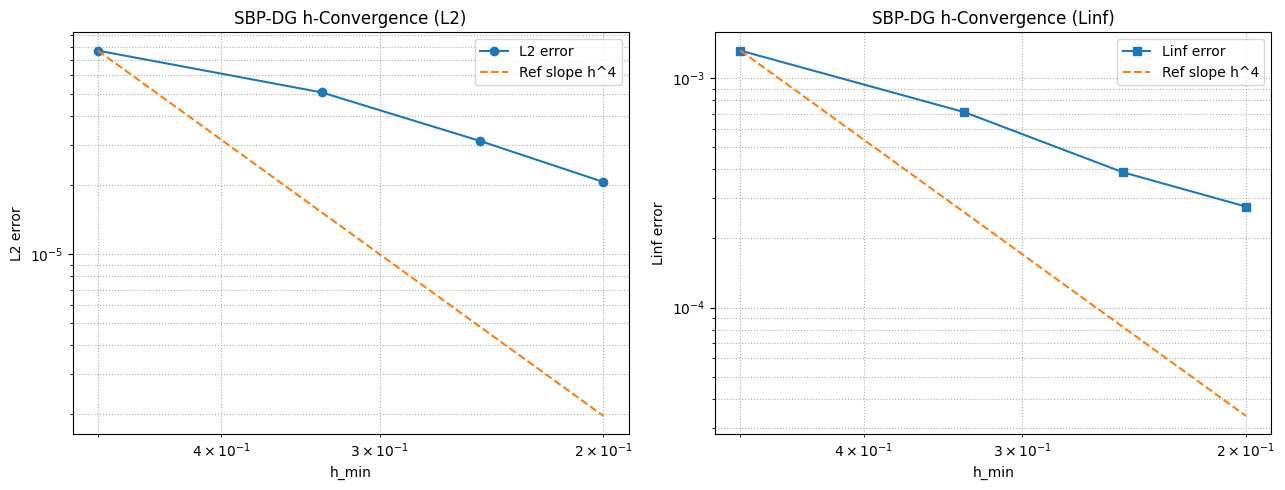

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ref_order = k + 1
ref_l2 = errors_l2[0] * (h_values / h_values[0]) ** ref_order
ref_linf = errors_linf[0] * (h_values / h_values[0]) ** ref_order

axes[0].loglog(h_values, errors_l2, 'o-', label='L2 error')
axes[0].loglog(h_values, ref_l2, '--', label=f'Ref slope h^{ref_order}')
axes[0].invert_xaxis()
axes[0].set_xlabel('h_min')
axes[0].set_ylabel('L2 error')
axes[0].set_title('SBP-DG h-Convergence (L2)')
axes[0].grid(True, which='both', ls=':')
axes[0].legend()

axes[1].loglog(h_values, errors_linf, 's-', label='Linf error')
axes[1].loglog(h_values, ref_linf, '--', label=f'Ref slope h^{ref_order}')
axes[1].invert_xaxis()
axes[1].set_xlabel('h_min')
axes[1].set_ylabel('Linf error')
axes[1].set_title('SBP-DG h-Convergence (Linf)')
axes[1].grid(True, which='both', ls=':')
axes[1].legend()

fig.tight_layout()
plt.show()